In [1]:
print("Churn project environment is working!")

Churn project environment is working!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = pd.read_csv("../data/raw/telco_churn_raw.csv")

print("Dataset loaded successfully!")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/telco_churn_raw.csv'

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

## 1. Dataset Overview

This section provides an initial understanding of the customer churn dataset, including its dimensions, features, data types, and basic statistical characteristics.

In [5]:
import os

print("Current notebook working folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current notebook working folder:
c:\Users\BAREEQ\OneDrive\Desktop\Customer-Churn-Prediction\notebooks

Files and folders here:
['01_data_exploration.ipynb']


In [6]:
import os

project_path = r"C:\Users\BAREEQ\OneDrive\Desktop\Customer-Churn-Prediction"

print("Project folder contains:")
print(os.listdir(project_path))

Project folder contains:
['app', 'data', 'graphs', 'models', 'notebooks', 'report', 'venv']


In [7]:
import os

data_path = r"C:\Users\BAREEQ\OneDrive\Desktop\Customer-Churn-Prediction\data"

print("Data folder contains:")
print(os.listdir(data_path))

Data folder contains:
['processed', 'raw']


In [8]:
import os

raw_path = r"C:\Users\BAREEQ\OneDrive\Desktop\Customer-Churn-Prediction\data\raw"

print("Raw folder contains:")
print(os.listdir(raw_path))

Raw folder contains:
['telco_churn_raw.csv.csv']


In [9]:
df = pd.read_csv("../data/raw/telco_churn_raw.csv.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

In [10]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(7043, 21)


In [11]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [12]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [14]:
print("Churn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# Overall Customer Churn Distribution

churn_counts = df["Churn"].value_counts()

colors = ["#2b5c8f", "#d9534f"]  # Blue = Retained, Red = Churned

plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Customer Churn Baseline Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "../graphs/01_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

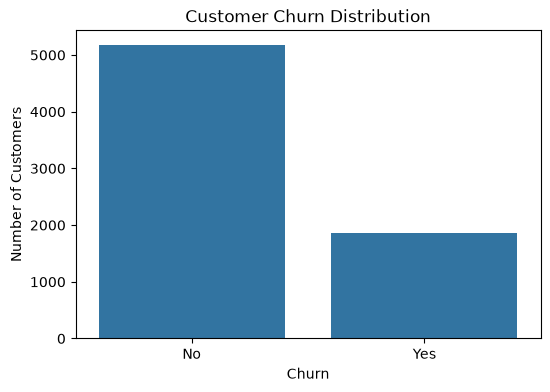

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
print("Summary statistics for numerical variables:")
print(df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe())

Summary statistics for numerical variables:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


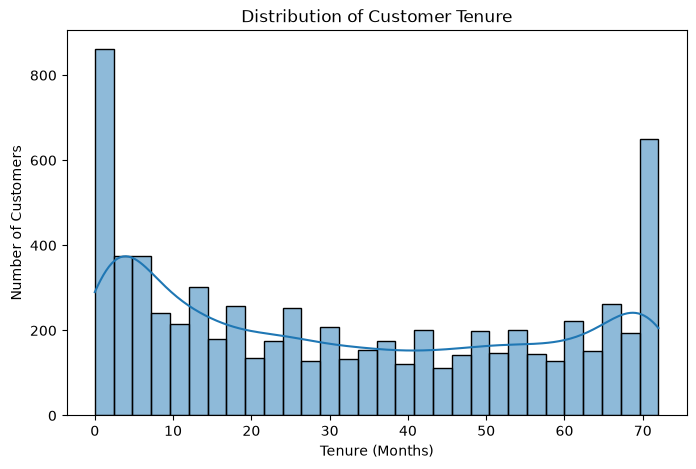

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

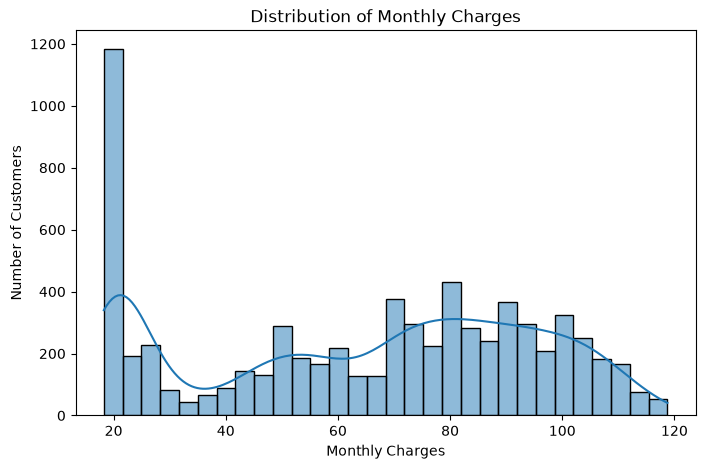

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
categorical_columns = df.select_dtypes(include="str").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


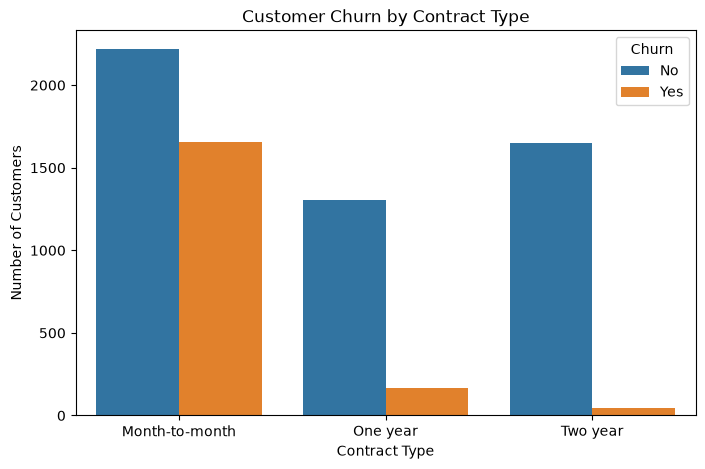

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn rate by contract type:")
print(contract_churn_rate)

Churn rate by contract type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


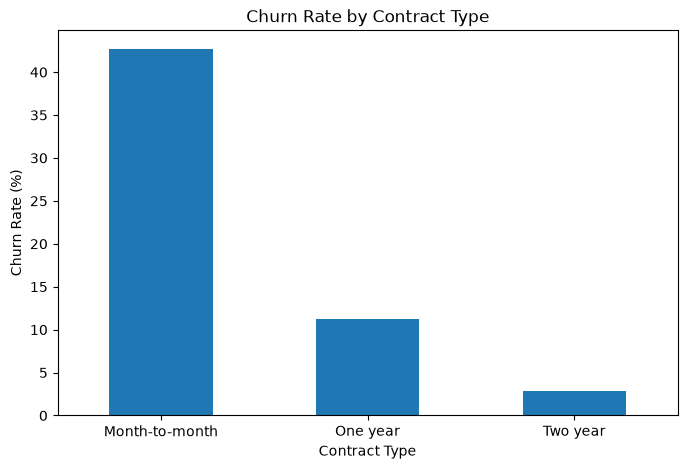

In [22]:
contract_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [23]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn rate by Internet Service:")
print(internet_churn_rate)

Churn rate by Internet Service:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


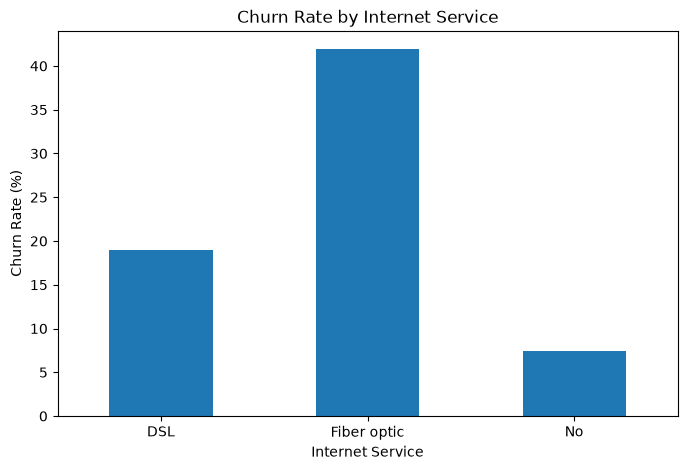

In [24]:
internet_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

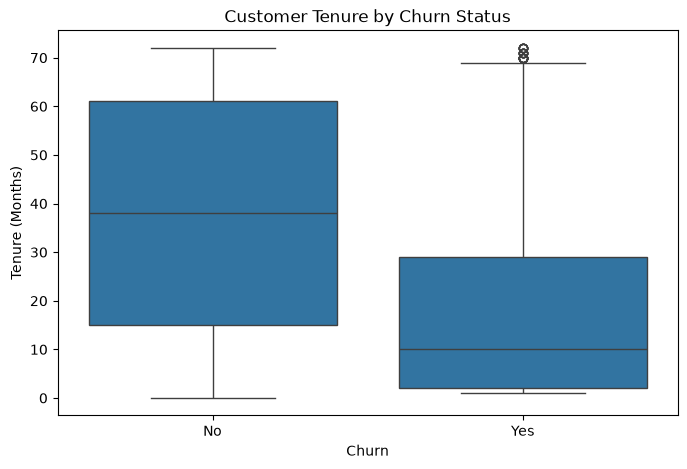

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [26]:
print("Average tenure by churn status:")
print(df.groupby("Churn")["tenure"].mean())

Average tenure by churn status:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


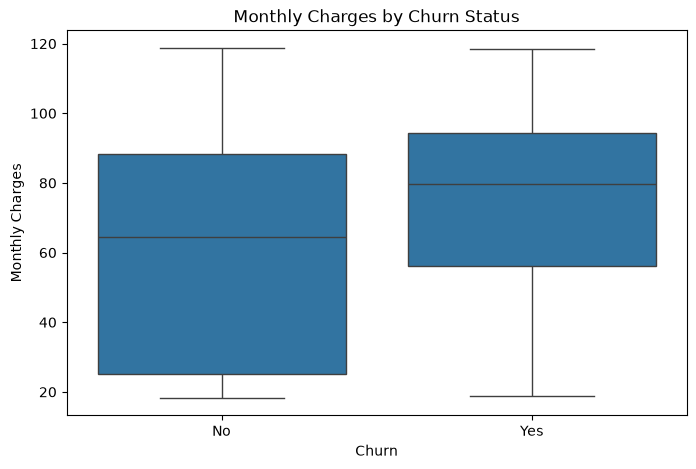

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [28]:
print("Average monthly charges by churn status:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

Average monthly charges by churn status:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [29]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn rate by payment method:")
print(payment_churn_rate)

Churn rate by payment method:
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


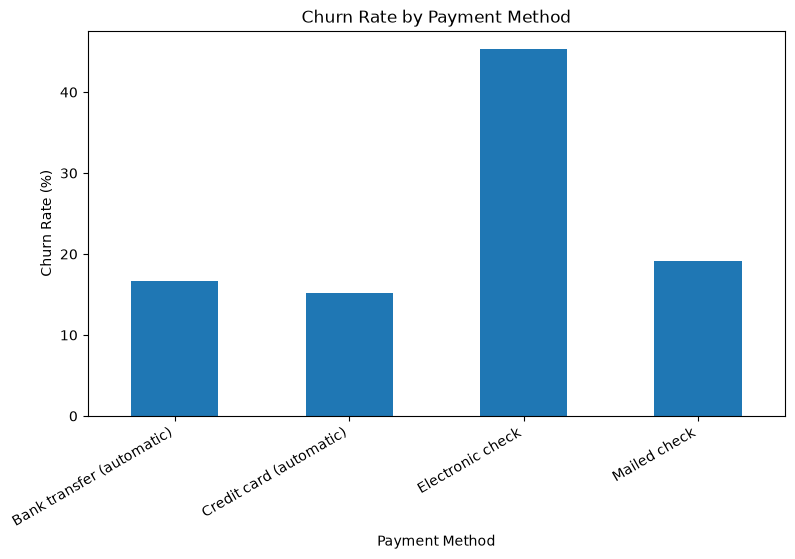

In [30]:
payment_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.show()

In [31]:
print("Sample TotalCharges values:")
print(df["TotalCharges"].head(20).tolist())

print("\nNumber of blank TotalCharges values:")
print((df["TotalCharges"].str.strip() == "").sum())

Sample TotalCharges values:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', '1862.9']

Number of blank TotalCharges values:
11


In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges data type:")
print(df["TotalCharges"].dtype)

print("\nMissing TotalCharges values after conversion:")
print(df["TotalCharges"].isnull().sum())

TotalCharges data type:
float64

Missing TotalCharges values after conversion:
11


In [33]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges values after cleaning:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges values after cleaning:
0


In [34]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nData types after cleaning:")
print(df.dtypes)

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types after cleaning:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling  

In [35]:
# Separate features and target

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [36]:
y = y.map({"No": 0, "Yes": 1})

print("Encoded target values:")
print(y.value_counts())

print("\nTarget data type:")
print(y.dtype)

Encoded target values:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target data type:
int64


In [37]:
categorical_features = X.select_dtypes(include="str").columns.tolist()
numerical_features = X.select_dtypes(exclude="str").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (5634, 19)
y_train: (5634,)

Testing set:
X_test: (1409, 19)
y_test: (1409,)


In [40]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully!

Original training shape: (5634, 19)
Processed training shape: (5634, 30)

Original testing shape: (1409, 19)
Processed testing shape: (1409, 30)


In [41]:
# Save the cleaned dataset

cleaned_path = "../data/processed/cleaned_data.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print("Location:", cleaned_path)

Cleaned dataset saved successfully!
Location: ../data/processed/cleaned_data.csv


In [42]:
# Save processed training features

X_train_df = pd.DataFrame(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

X_train_df.to_csv(
    "../data/processed/X_train_processed.csv",
    index=False
)

print("X_train_processed saved successfully!")

X_train_processed saved successfully!


In [43]:
# Save processed testing features

X_test_df = pd.DataFrame(
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_df.to_csv(
    "../data/processed/X_test_processed.csv",
    index=False
)

print("X_test_processed saved successfully!")

X_test_processed saved successfully!


In [44]:
# Save training target

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

print("y_train saved successfully!")

y_train saved successfully!


In [45]:
import joblib

joblib.dump(
    preprocessor,
    "../data/processed/preprocessor.pkl"
)

print("Preprocessing pipeline saved successfully!")

Preprocessing pipeline saved successfully!


In [46]:
# Save testing target

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

print("y_test saved successfully!")

y_test saved successfully!
